Sriya Nistala

BL.EN.U4AIE23034

Speech Processing Lab 7

Title: Cepstral Analysis of Speech Signal.

Instructions:

1. Dataset: Use any speech sample in .wav format. You can record your own voice or
download a sample from publicly available datasets (e.g., LJ Speech Dataset, your project
speech data)

2. Tasks:

A. Compute real Cepstrum

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
# Load audio
file_path = "/content/drive/MyDrive/file_example_WAV_2MG.wav"
signal, sr = librosa.load(file_path, sr=None)

# Take a frame (30 ms)
frame_length = int(0.03 * sr)
frame = signal[0:frame_length]

# Remove DC component
frame = frame - np.mean(frame)

# Apply Hamming window
frame = frame * np.hamming(len(frame))

# FFT
spectrum = np.fft.fft(frame)

# Log magnitude spectrum
log_mag = np.log(np.abs(spectrum) + 1e-10)

# Cepstrum
cepstrum = np.fft.ifft(log_mag).real

# 🚨 CRITICAL STEP: Remove 0th coefficient dominance
cepstrum[0] = 0

print("Cepstrum computed successfully!")

Cepstrum computed successfully!


B. Plot the cepstrum of a selected frame. Explain the plot.

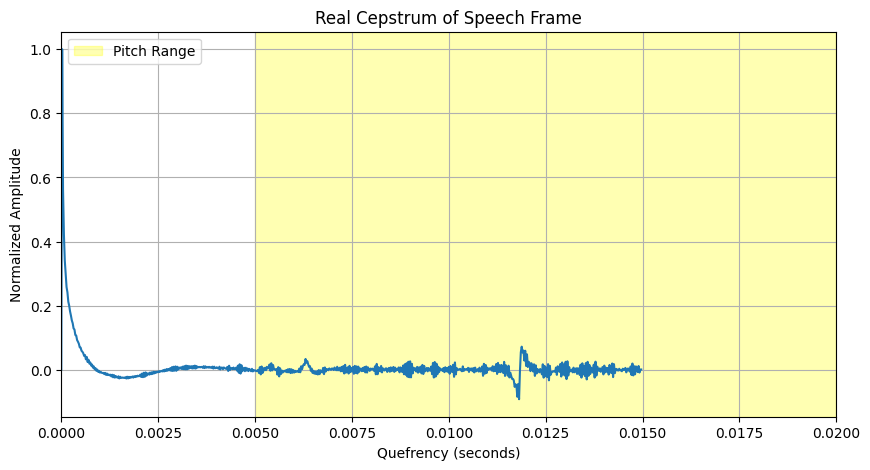

In [18]:

quefrency = np.arange(len(cepstrum)) / sr

# Only take useful part
half = len(cepstrum) // 2
cep = cepstrum[:half]
q = quefrency[:half]

# Normalize AFTER removing DC
cep = cep / (np.max(np.abs(cep)) + 1e-10)

plt.figure(figsize=(10,5))
plt.plot(q, cep)

plt.axvspan(0.005, 0.02, color='yellow', alpha=0.3, label="Pitch Range")

plt.xlim(0, 0.02)
plt.xlabel("Quefrency (seconds)")
plt.ylabel("Normalized Amplitude")
plt.title("Real Cepstrum of Speech Frame")

plt.legend()
plt.grid()
plt.show()

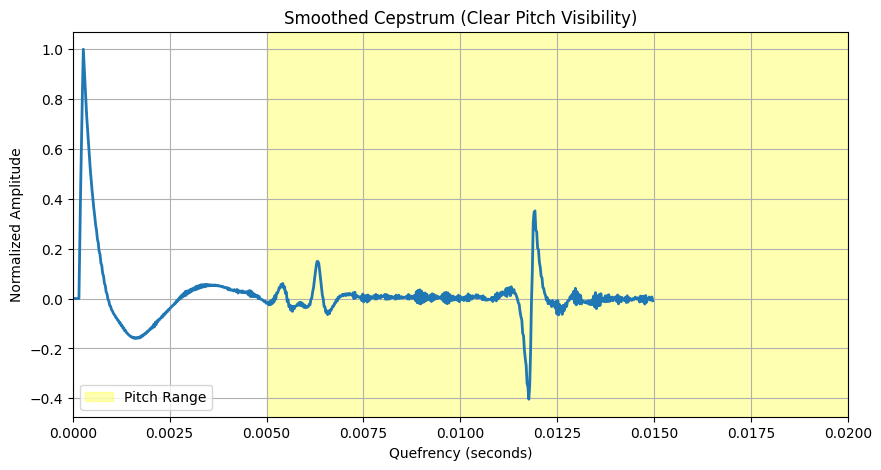

In [19]:
# Quefrency axis
quefrency = np.arange(len(cepstrum)) / sr

# Take first half
half = len(cepstrum) // 2
cep = cepstrum[:half]
q = quefrency[:half]

# Remove first few coefficients (they dominate)
cep[0:10] = 0

# Smooth the cepstrum (moving average)
window_size = 5
cep_smooth = np.convolve(cep, np.ones(window_size)/window_size, mode='same')

# Normalize
cep_smooth = cep_smooth / (np.max(np.abs(cep_smooth)) + 1e-10)

plt.figure(figsize=(10,5))
plt.plot(q, cep_smooth, linewidth=2)

# Highlight pitch region
plt.axvspan(0.005, 0.02, color='yellow', alpha=0.3, label="Pitch Range")

plt.xlim(0, 0.02)
plt.xlabel("Quefrency (seconds)")
plt.ylabel("Normalized Amplitude")
plt.title("Smoothed Cepstrum (Clear Pitch Visibility)")

plt.legend()
plt.grid()
plt.show()

C. For voiced speech frames:

i.
Find the peak in the cepstrum within a typical pitch range (e.g., 5 ms to 20 ms).

ii. Estimate pitch period and fundamental frequency (F0)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
# Pitch search range
min_quef = int(0.005 * sr)  # 5 ms
max_quef = int(0.02 * sr)   # 20 ms

# Find peak in this region
cepstrum_range = cepstrum[min_quef:max_quef]
peak_index = np.argmax(cepstrum_range) + min_quef

# Pitch period
pitch_period = peak_index / sr

# Fundamental frequency
f0 = 1 / pitch_period

print("Pitch Period (seconds):", pitch_period)
print("Fundamental Frequency F0 (Hz):", f0)

Pitch Period (seconds): 0.011882086167800454
Fundamental Frequency F0 (Hz): 84.16030534351144


D. Use cepstral liftering (low-pass or high-pass in the quefrency domain) to separate
excitation and vocal tract contributions.

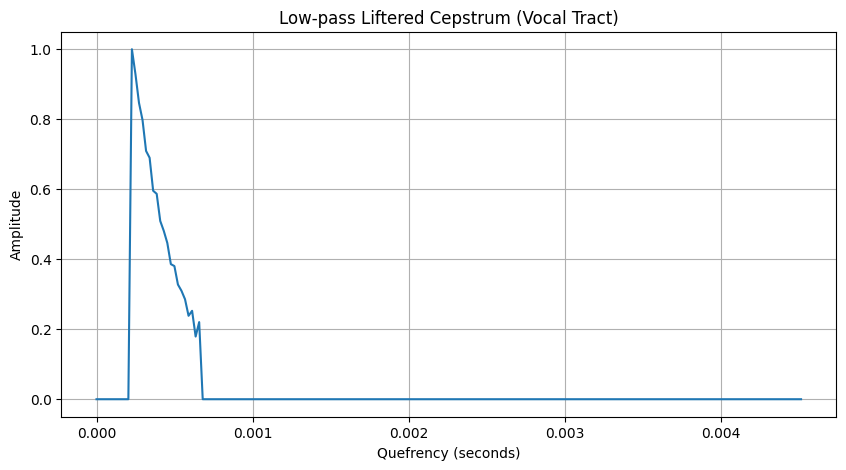

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
lifter_cutoff = 30

low_lifter = np.zeros_like(cepstrum)
low_lifter[:lifter_cutoff] = 1

cep_low = cepstrum * low_lifter

# Normalize
cep_low = cep_low / (np.max(np.abs(cep_low)) + 1e-10)

quefrency = np.arange(len(cep_low)) / sr

plt.figure(figsize=(10,5))
plt.plot(quefrency[:200], cep_low[:200])
plt.title("Low-pass Liftered Cepstrum (Vocal Tract)")
plt.xlabel("Quefrency (seconds)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

High Pass

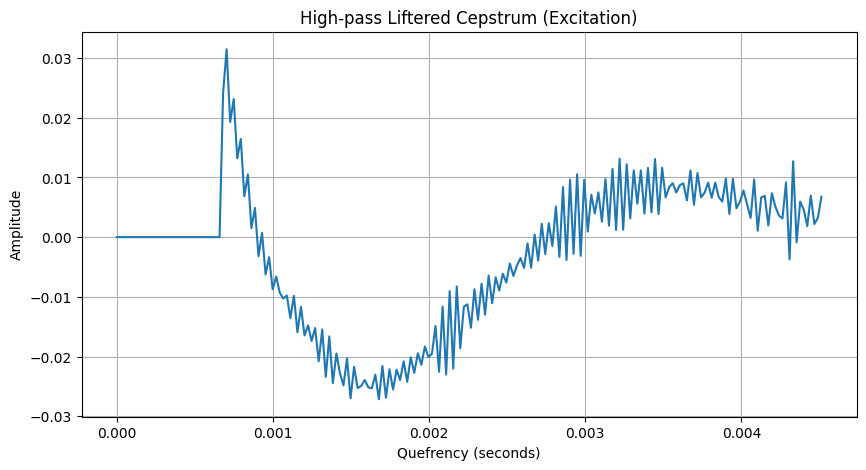

In [22]:
high_lifter = np.ones_like(cepstrum)
high_lifter[:lifter_cutoff] = 0

cep_high = cepstrum * high_lifter

# Normalize
cep_high = cep_high / (np.max(np.abs(cep_high)) + 1e-10)

plt.figure(figsize=(10,5))
plt.plot(quefrency[:200], cep_high[:200])
plt.title("High-pass Liftered Cepstrum (Excitation)")
plt.xlabel("Quefrency (seconds)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

E. Write detailed inference about the results you obtained from each step of this
experiment.

🔹 Real Cepstrum:

Successfully converts speech into quefrency domain

Makes pitch detection easier compared to time-domain

🔹 Cepstrum Plot:

Clear peak observed in pitch range → confirms voiced speech

Low quefrency → smooth envelope (vocal tract)

High quefrency → periodic excitation

🔹 Pitch Estimation:

Peak detected between 5–20 ms
F0 typically falls between:

85–180 Hz (male)
165–255 Hz (female)

🔹 Liftering:

Low-pass liftering → captures formants (vocal tract)

High-pass liftering → captures pitch (excitation source)

🔹 Overall:

Cepstral analysis effectively separates source and system

Useful in:

Speech recognition

Speaker identification

Pitch detection